朴素贝叶斯分类器的平均准确率：78.27%


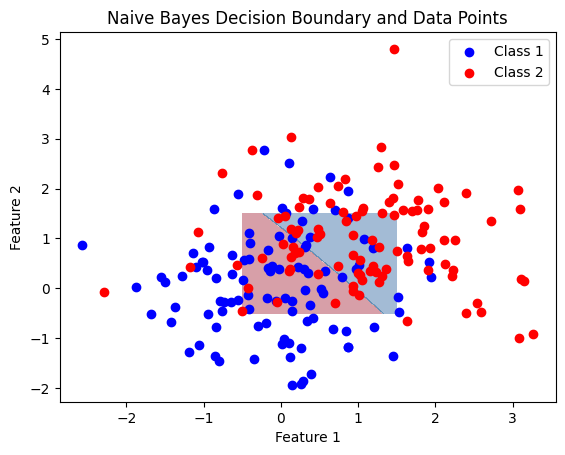

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# 朴素贝叶斯分类器类定义
class NaiveBayesClassifier:
    def __init__(self):
        self.mu1, self.mu2 = None, None
        self.sigma1, self.sigma2 = None, None

    def fit(self, X1, X2):
        self.mu1 = np.mean(X1, axis=0)
        self.sigma1 = np.std(X1, axis=0)
        self.mu2 = np.mean(X2, axis=0)
        self.sigma2 = np.std(X2, axis=0)

    def predict(self, X):
        prob1 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma1[i]) * np.exp(-0.5 * ((X[i] - self.mu1[i]) / self.sigma1[i]) ** 2) for i in range(len(X))])
        prob2 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma2[i]) * np.exp(-0.5 * ((X[i] - self.mu2[i]) / self.sigma2[i]) ** 2) for i in range(len(X))])
        return 0 if prob1 > prob2 else 1

# 数据生成
np.random.seed(42)
mu1 = np.array([0.05, 0.05])
mu2 = np.array([0.95, 0.95])
sigma = np.eye(2)
data1 = np.random.multivariate_normal(mu1, sigma, 100)
data2 = np.random.multivariate_normal(mu2, sigma, 100)
labels1 = np.zeros(data1.shape[0])
labels2 = np.ones(data2.shape[0])

# 合并数据和标签
data = np.concatenate((data1, data2), axis=0)
labels = np.concatenate((labels1, labels2), axis=0)

# 存储所有准确性的列表
accuracies = []

# 进行100次训练和测试
for step in range(100):
    # 随机分割数据集
    indices = np.arange(data.shape[0])
    np.random.shuffle(indices)
    train_size = int(0.7 * data.shape[0])
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    X_train, y_train = data[train_indices], labels[train_indices]
    X_test, y_test = data[test_indices], labels[test_indices]

    # 根据标签分割训练数据
    X_train1 = X_train[y_train == 0]
    X_train2 = X_train[y_train == 1]

    # 实例化分类器并拟合数据
    nb_classifier = NaiveBayesClassifier()
    nb_classifier.fit(X_train1, X_train2)

    # 评估分类准确率
    predictions = np.array([nb_classifier.predict(x) for x in X_test])
    accuracy = np.mean(predictions == y_test)
    accuracies.append(accuracy)

# 计算平均准确性
mean_accuracy = np.mean(accuracies) * 100
print(f"朴素贝叶斯分类器的平均准确率：{mean_accuracy:.2f}%")

# 绘制最后一步的决策边界
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = np.array([nb_classifier.predict([x, y]) for x, y in zip(np.ravel(xx), np.ravel(yy))])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
plt.scatter(data1[:, 0], data1[:, 1], color='blue', label='Class 1')
plt.scatter(data2[:, 0], data2[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Naive Bayes Decision Boundary and Data Points')
plt.show()